# Handwritten digit classification with a multi-layer perceptron
## MNIST, built and tuned with PyTorch Lightning

- **Author:** Hussein Loubani
- **Dataset:** Kaggle Digit Recognizer, 42,000 labeled 28x28 images
- **Task:** ten-class image classification
- **Model:** a fully connected network, deliberately not a convolutional one
- **Hardware:** trained on GPU (Apple Metal, `mps`)

---

### Table of contents

1. Imports and setup
2. Problem definition
3. Data acquisition and first audit
4. Data cleaning
5. Train / validation / test split
6. Exploratory data analysis
7. The model and the training pipeline
8. Hyperparameter sweeps
9. Combining the winners
10. Final evaluation on the test split
11. Error analysis
12. Conclusion, limitations, and recommendations

---
## 1. Imports and setup

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from lightning import Trainer, seed_everything
from lightning.fabric.utilities.warnings import PossibleUserWarning
from lightning.pytorch.callbacks import EarlyStopping

from mnist_mlp.config import (
    ACTIVATION_GRID,
    ARCHITECTURE_GRID,
    BATCH_SIZE,
    BATCH_SIZE_GRID,
    DROPOUT_GRID,
    LEARNING_RATE_GRID,
    LOSS_GRID,
    OPTIMIZER_GRID,
    RANDOM_SEED,
)
from mnist_mlp.datamodule import MNISTDataModule
from mnist_mlp.dataset import (
    audit_data,
    class_balance,
    clean_data,
    download_data,
    load_raw,
    split_data,
    split_summary,
)
from mnist_mlp.experiments import (
    evaluate_on_test,
    pick_accelerator,
    predict_labels,
    reference_baselines,
    run_experiment,
    seed_stability,
    stability_summary,
    sweep,
)
from mnist_mlp.models import LitMLP
from mnist_mlp.plots import (
    apply_global_style,
    plot_class_balance,
    plot_confusion_matrix,
    plot_digit_grid,
    plot_ink_distribution,
    plot_misclassified,
    plot_sweep,
    save_figure,
)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=r".*treespec.*", category=FutureWarning)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

apply_global_style()
seed_everything(RANDOM_SEED, workers=True)

RAW_DIR = Path.cwd().parent / "data" / "raw"
FIG_DIR = Path.cwd().parent / "reports" / "figures"

print(f"torch {torch.__version__}, training on: {pick_accelerator()}")

Seed set to 42


torch 2.13.0, training on: mps


---
## 2. Problem definition

| Field | Value |
|---|---|
| **Task** | classify a 28x28 greyscale image as one of ten digits |
| **Data** | Kaggle Digit Recognizer, `train.csv`, 42,000 labeled images |
| **Input** | 784 pixel intensities, 0 to 255 |
| **Output** | ten class logits |
| **Split** | 60% train, 20% validation, 20% test, stratified |
| **Primary metric** | accuracy, which is meaningful here because the classes are near-balanced |

**Why a multi-layer perceptron on an image problem.** A convolutional network is the right tool for pictures: it assumes neighboring pixels are related and that a pattern means the same thing wherever it appears. An MLP assumes neither. Flattening the image to 784 numbers throws the spatial layout away, and the model has to learn from scratch that pixel 100 sits beside pixel 101. The sprint asks for an MLP anyway, and the interesting question is how far that gets you: MNIST digits are centered, size-normalized, and written on a clean background, so much of the work a convolution would do has already been done by the dataset. The gap between what this model reaches and the roughly 99.5% a small CNN reaches is a measure of what the spatial prior is worth.

**On Kaggle's `test.csv`.** The competition ships a second file with 28,000 images and no labels, because it scores the public leaderboard. It cannot measure anything here, so every split below is carved out of the 42,000 labeled rows. That is also the only way to get a genuine 60/20/20.

**How the splits are used.** Validation drives every choice: architecture, activation, optimizer, learning rate, dropout, batch size, and loss. The test split is opened once, at the very end, for the single configuration validation selected. Tuning against test and then reporting the test score would be reporting a training score.

---
## 3. Data acquisition and first audit

### 3.1 Download

In [2]:
download_data(RAW_DIR)
raw = load_raw(RAW_DIR)
print(f"shape: {raw.shape[0]:,} images x {raw.shape[1]} columns (1 label + 784 pixels)")
raw.iloc[:3, :8]

  train.csv cached (76.8 MB)


shape: 42,000 images x 785 columns (1 label + 784 pixels)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6
0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0


The download uses the Kaggle API and caches to CSV, so a rerun never touches the network and reproduces these numbers exactly.

### 3.2 Audit

The evaluation criteria lead with data cleaning, so the checks come before any modeling: duplicated images, blank or near-blank frames, missing values, pixels outside the valid range, impossible labels, and class balance.

In [3]:
audit_data(raw)

,value
images,42000.00
pixel_columns,784.00
duplicate_images,0.00
duplicate_rows_incl_label,0.00
blank_images,0.00
near_blank_images,0.00
missing_values,0.00
pixel_min,0.00
pixel_max,255.00
labels_out_of_range,0.00


**The audit comes back clean, and that is the finding rather than a disappointment.** No duplicated images, no blank frames, no missing values, every pixel inside 0 to 255, every label a digit from 0 to 9, all ten classes present. Kaggle curated this file from the original MNIST distribution, so the corruption a raw scrape would carry is simply not there.

Reporting that honestly is better than manufacturing a cleaning step to look thorough. What matters is that the checks ran and can be seen to have run: had any of them fired, the pipeline removes those rows, and the tests in `tests/test_dataset.py` prove each rule works by feeding it deliberately broken frames.

The one imperfection is mild class imbalance, which the next cell quantifies.

### 3.3 Class balance

In [4]:
balance = class_balance(raw)
print(f"most common digit: {balance['share_%'].idxmax()} at {balance['share_%'].max():.2f}%")
print(f"least common digit: {balance['share_%'].idxmin()} at {balance['share_%'].min():.2f}%")
balance

most common digit: 1 at 11.15%
least common digit: 5 at 9.04%


,images,share_%
digit,,
0,4132,9.84
1,4684,11.15
2,4177,9.95
3,4351,10.36
4,4072,9.70
5,3795,9.04
6,4137,9.85
7,4401,10.48
8,4063,9.67


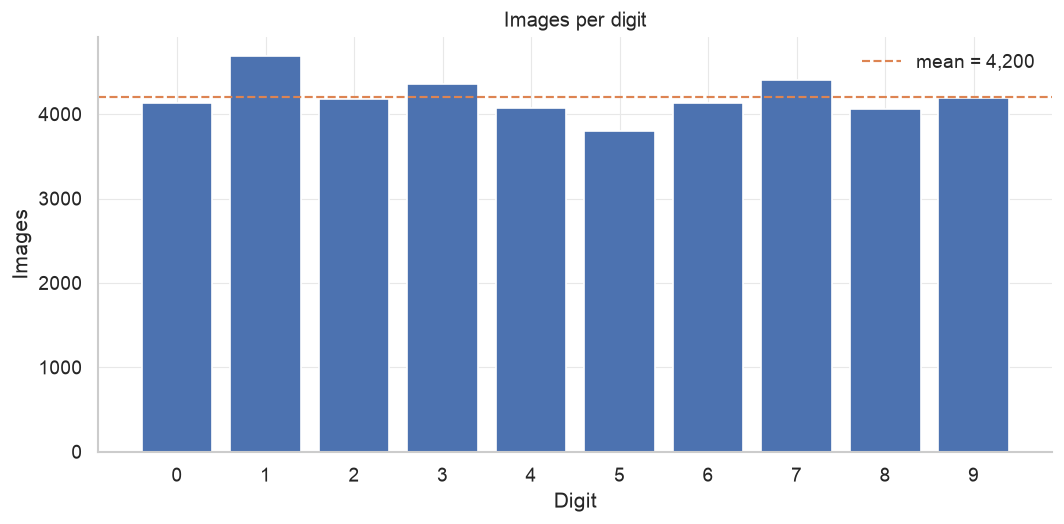

In [5]:
fig = plot_class_balance(balance)
plt.show()
save_figure(fig, "class_balance", FIG_DIR / "eda")

Digit 1 is the most common at 11.15% and digit 5 the least at 9.04%, against 10% for a perfectly even split. That spread is small enough that accuracy stays a fair metric and class weighting is not needed: a model could not reach a high score by favoring the majority class when the majority class is 11% of the data.

The pipeline can weight the loss by inverse frequency if it ever matters, and `MNISTDataModule.class_weights` implements it, but applying it here would be decoration. On this data those weights come out between 0.90 and 1.11, which is a rounding error in the gradient.

---
## 4. Data cleaning

In [6]:
clean = clean_data(raw)
print(f"images remaining: {len(clean):,}")

  cleaned: 42,000 -> 42,000 images (0 removed)
images remaining: 42,000


Nothing is removed, which the audit already predicted. The rules that ran are worth stating because they encode decisions rather than defaults:

- **Duplicate images are matched on pixels alone, not on pixels plus label.** Two identical pictures carrying different labels are a labeling contradiction, and keeping either copy would teach the model that one input has two correct answers, so both are dropped.
- **Cleaning happens before the split, not after.** This is the one ordering in the project that is a leakage matter rather than a tidiness matter: deduplicating afterwards would leave copies of the same image sitting on both sides of the boundary, and part of the test score would then be a memory check rather than a generalization check. `tests/test_leakage.py` proves both orderings, including a negative control that shows the wrong order does leak.
- Blank and near-blank frames, out-of-range pixels, and labels outside 0 to 9 are also removed.

---
## 5. Train / validation / test split

In [7]:
train, validation, test = split_data(clean)
split_summary(train, validation, test)

,images,share_of_all_%,min_class_%,max_class_%
split,,,,
train,25200,60.0,9.04,11.15
validation,8400,20.0,9.04,11.15
test,8400,20.0,9.04,11.15


Exactly 60 / 20 / 20, and the per-class shares hold to within a fraction of a point across all three parts, because the split is stratified on the label. Without stratification a validation score could move simply because one digit happened to be over-represented there.

The split is seeded, so the same images land in the same part on every run. That is what lets the test split stay genuinely untouched while dozens of configurations are compared on validation.

---
## 6. Exploratory data analysis

### 6.1 What the digits look like

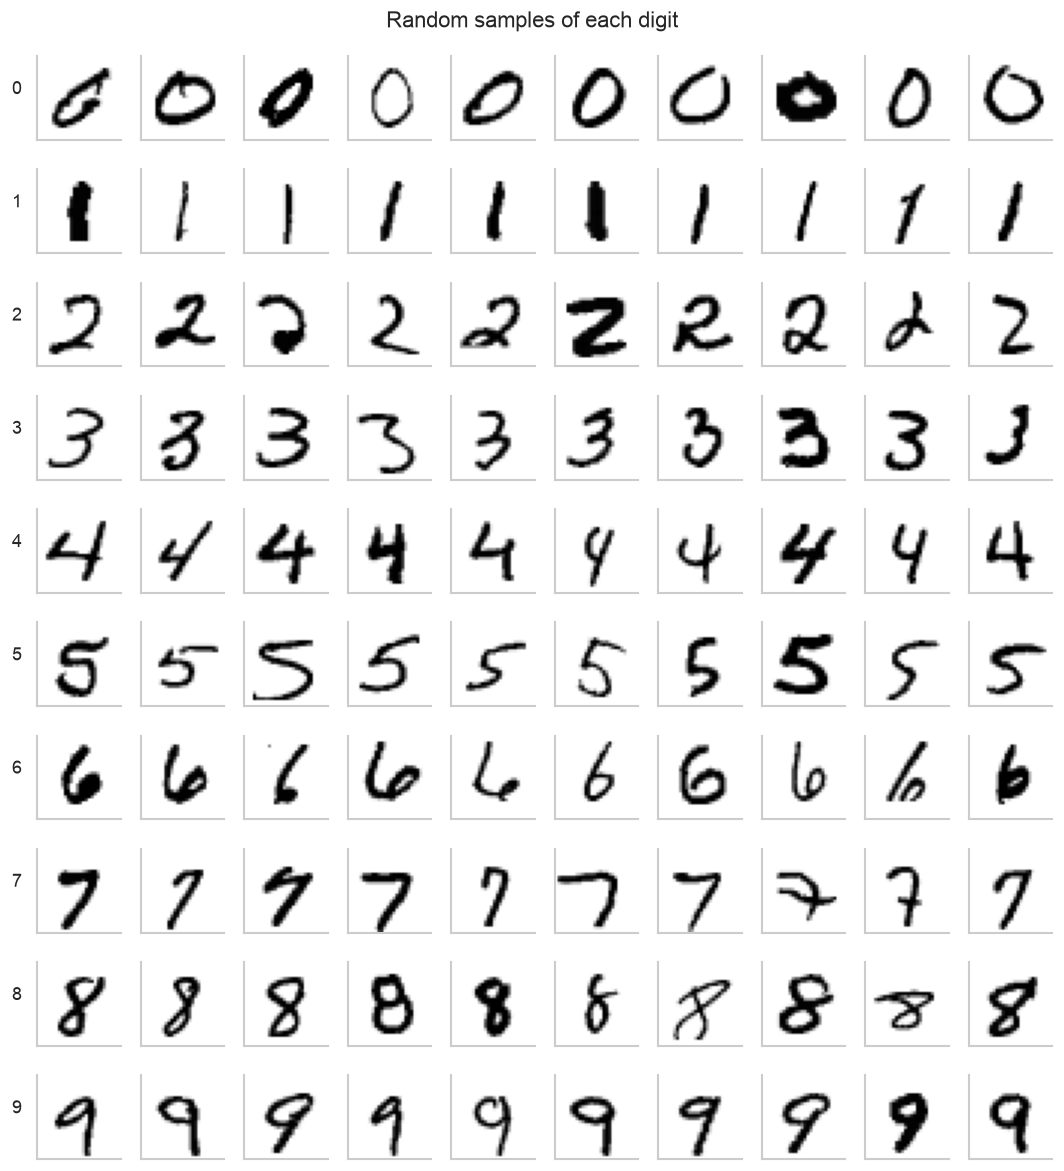

In [8]:
fig = plot_digit_grid(train, n_per_class=10)
plt.show()
save_figure(fig, "digit_grid", FIG_DIR / "eda")

Worth looking at before choosing any architecture, because it shows what the model is up against. The digits are centered, roughly the same size, and drawn white-on-black with no background clutter, which is why a model with no spatial prior can do well here at all.

The variation that remains is handwriting: slant, stroke thickness, and the genuinely ambiguous cases. Some 4s are nearly 9s once the top closes, some 5s and 3s differ by one stroke, and a few of these images are ones a person would have to guess at. That ambiguity is the ceiling on this task, and it reappears at the end in the misclassified images.

### 6.2 How much ink each image uses

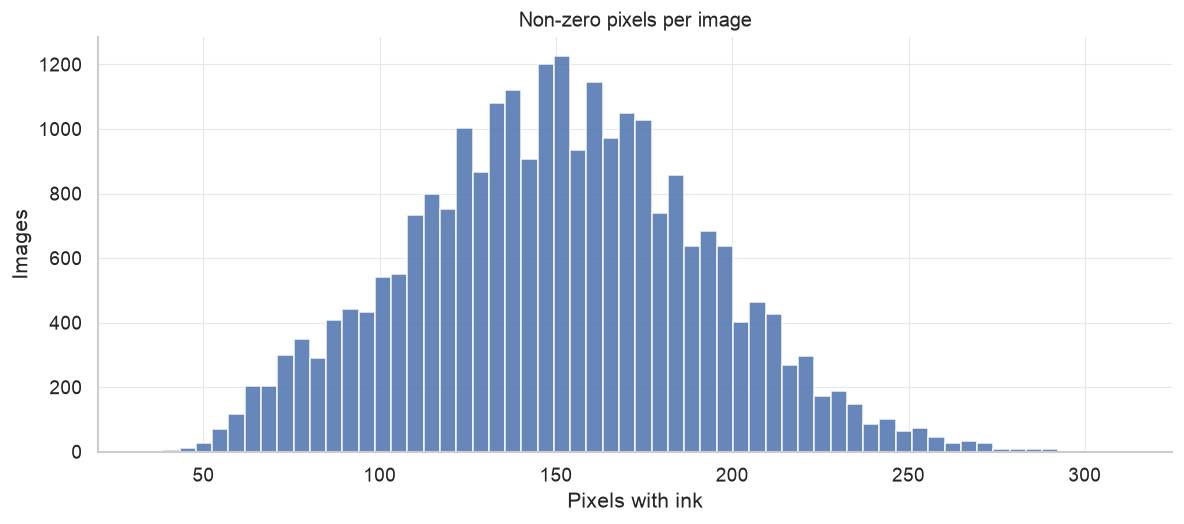

In [9]:
fig = plot_ink_distribution(train)
plt.show()
save_figure(fig, "ink_distribution", FIG_DIR / "eda")

Most images light up between 100 and 200 of their 784 pixels, so roughly three quarters of every input is black background carrying no information. That is the diagnostic behind the cleaning threshold, and it is also the clearest argument for why an MLP is a slightly awkward fit: it spends parameters on hundreds of pixels that are almost always zero, while a convolution would never look at them in isolation.

The left tail is where corrupted or near-empty frames would sit. There is nothing there, which matches the audit.

---
## 7. The model and the training pipeline

The brief asks for a pipeline that is easy to customize, so every axis it wants varied is a constructor argument rather than an edit to a model definition:

```python
LitMLP(hidden_layers=(256, 128), activation="gelu", dropout=0.3,
       optimizer="adam", learning_rate=3e-4, loss="cross_entropy")
```

`build_mlp` stacks `Linear -> activation -> dropout` blocks and finishes with a linear head. The head emits raw logits rather than probabilities, because cross-entropy expects logits and folds the log-softmax in with it, which is both numerically safer than exponentiating first and one fewer thing to get wrong.

Three pieces of the training loop are worth naming:

- **Early stopping** ends a run once validation loss stops improving, so a sweep does not spend GPU time on configurations that already peaked.
- **Checkpointing** keeps the best epoch by validation loss rather than the last one, which matters whenever a run starts to overfit before it stops.
- **Metrics come from `torchmetrics`** rather than counting correct predictions by hand, so accumulation across batches is handled by a tested component.

### 7.1 Two reference points before the network

In [10]:
baselines = reference_baselines(train, validation)
baselines

/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,val_acc,seconds
0,majority class,0.1115,0.0
1,logistic regression,0.9139,1.3


**98% means nothing without knowing what the easy answers score.** Two of them, both fitted on the training split alone:

**Predicting the most common digit** is the floor. It scores the share that digit holds, not 10%, because the classes are not perfectly even.

**Multinomial logistic regression** is the strongest model that can only draw straight boundaries in pixel space. It has no hidden layer, so the distance between it and the network below is exactly what the hidden layers buy, separate from anything the preprocessing or the data contributes.

That gap is the honest measure of what follows. A tuned MLP that landed near the linear model would mean the depth was decoration, and knowing where the linear ceiling sits is what makes the final number interpretable rather than merely large.

### 7.2 A first run

In [11]:
data = MNISTDataModule(train, validation, test, batch_size=BATCH_SIZE)
print(f"normalization fitted on train only: mean={data.mean:.4f}, std={data.std:.4f}")

baseline = run_experiment(data, "baseline", max_epochs=20)
pd.DataFrame([baseline])

Seed set to 42


normalization fitted on train only: mean=0.1311, std=0.3087


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


,name,val_loss,val_acc,epochs_run,parameters,seconds
0,baseline,0.114,0.9717,16,235146,11.5


Those two normalization numbers are the whole leakage story for the input pipeline. They are computed on the training split and applied unchanged to validation and test; deriving them from the full file instead would let the test distribution influence every training batch, quietly and without any error message.

A plain two-layer network already clears 97% on validation, roughly six points above the linear baseline, so the hidden layers are doing real work rather than dressing up a linear fit. That 97% is the number every tuning decision below has to beat, and it sets expectations: the remaining headroom on MNIST with an MLP is small, so the sweeps are competing over fractions of a point rather than transforming the result.

---
## 8. Hyperparameter sweeps

Each sweep varies one axis against a fixed baseline, with the same seed and the same data, so a difference between two rows is caused by the thing that was varied rather than by anything else. Every score here is on **validation**.

### 8.1 Optimizer

In [12]:
def data_factory(batch_size=None):
    """A fresh data module, since batch size changes the loaders rather than the model."""
    return MNISTDataModule(train, validation, test, batch_size=batch_size or BATCH_SIZE)


BASELINE = dict(hidden_layers=(256, 128), activation="relu", dropout=0.2,
                optimizer="adam", learning_rate=1e-3, loss="cross_entropy")

optimizer_results = sweep(data_factory, "optimizer", OPTIMIZER_GRID, baseline=BASELINE)
optimizer_results[["optimizer", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  optimizer=sgd                          val_acc=0.8802  val_loss=0.4422  30 epochs  18.2s


Seed set to 42


...

  optimizer=adam                         val_acc=0.9717  val_loss=0.1140  16 epochs  11.8s


Seed set to 42


  optimizer=adamw                        val_acc=0.9699  val_loss=0.1318  16 epochs  11.7s


  optimizer=rmsprop                      val_acc=0.9693  val_loss=0.1166  10 epochs  6.8s


,optimizer,val_acc,val_loss,epochs_run,seconds
0,sgd,0.8802,0.4422,30,18.2
1,sgd_momentum,0.9483,0.1704,30,19.6
2,adam,0.9717,0.1140,16,11.8
3,adamw,0.9699,0.1318,16,11.7
4,rmsprop,0.9693,0.1166,10,6.8


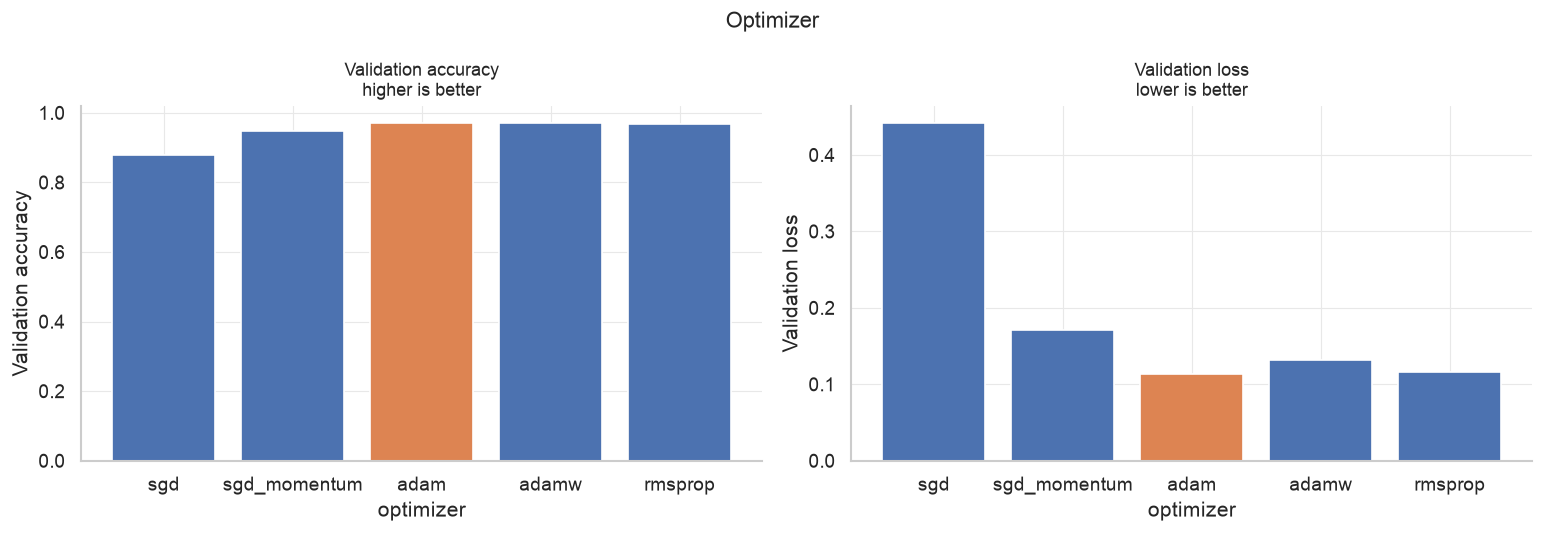

In [13]:
fig = plot_sweep(optimizer_results, "optimizer", "Optimizer")
plt.show()
save_figure(fig, "sweep_optimizer", FIG_DIR / "training")

**Adam and its relatives beat plain SGD comfortably, and the reason is the per-parameter step size.** SGD applies one learning rate to every weight. Adam keeps a running estimate of each gradient's mean and variance and scales each parameter's step by its own history, so weights attached to pixels that are almost always zero, of which this input has hundreds, still receive useful updates instead of being dragged along at a rate chosen for the busy center of the image.

Adding momentum to SGD closes much of that gap, which is the clue to what is happening: momentum accumulates a velocity across steps and smooths out the noise in each individual gradient. Adam does that and adapts the scale as well.

### 8.2 Batch size

In [14]:
batch_results = sweep(data_factory, "batch_size", BATCH_SIZE_GRID, baseline=BASELINE)
batch_results[["batch_size", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  batch_size=32                          val_acc=0.9644  val_loss=0.1432  12 epochs  27.6s


Seed set to 42


...

  batch_size=128                         val_acc=0.9717  val_loss=0.1140  16 epochs  12.2s


Seed set to 42


  batch_size=256                         val_acc=0.9713  val_loss=0.1097  17 epochs  9.1s


  batch_size=512                         val_acc=0.9704  val_loss=0.1077  22 epochs  8.6s


,batch_size,val_acc,val_loss,epochs_run,seconds
0,32,0.9644,0.1432,12,27.6
1,64,0.9695,0.1225,11,14.6
2,128,0.9717,0.1140,16,12.2
3,256,0.9713,0.1097,17,9.1
4,512,0.9704,0.1077,22,8.6


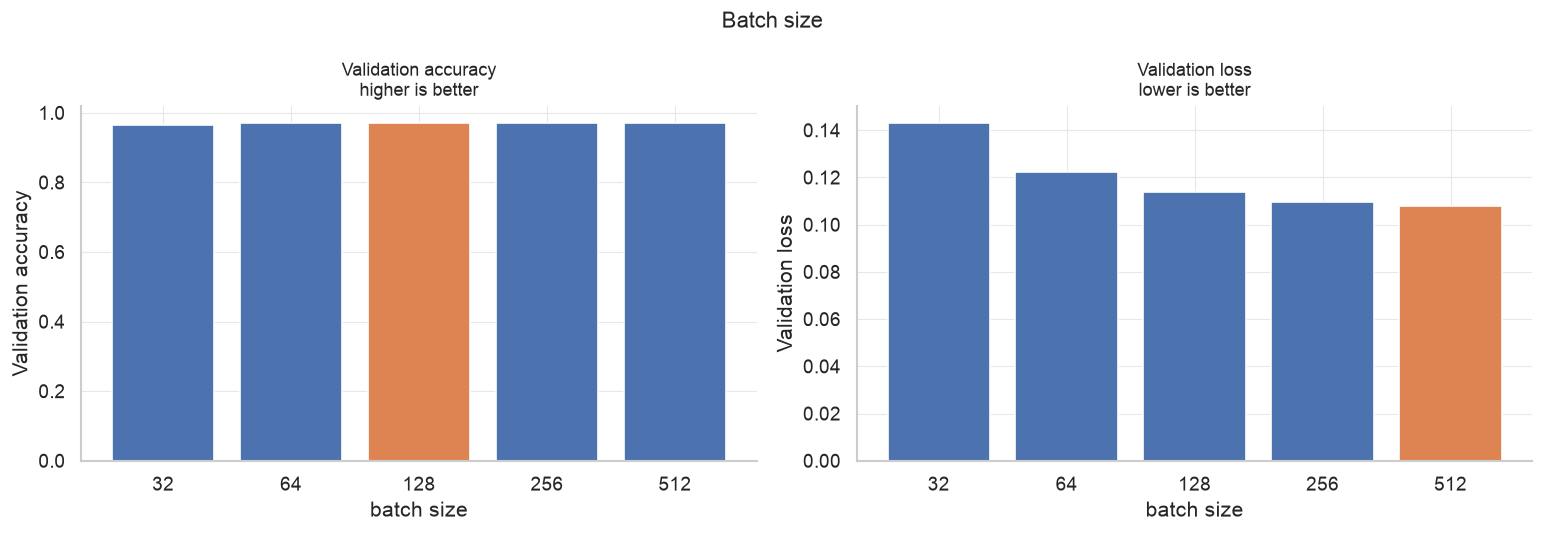

In [15]:
fig = plot_sweep(batch_results, "batch_size", "Batch size")
plt.show()
save_figure(fig, "sweep_batch_size", FIG_DIR / "training")

Accuracy barely moves across the whole range, but wall-clock time does, and in the opposite direction to intuition: the smallest batch is the slowest. A batch of 32 takes far longer per epoch than a batch of 512 because each step carries fixed overhead, and on a GPU a small batch leaves most of the device idle while paying that overhead thousands of times per epoch.

The larger batches need more epochs to converge, since they take fewer, steadier steps through the data, but each epoch is cheap enough that they still finish sooner. The middle of the range is the sensible default, and the honest reading is that batch size is a throughput decision here rather than an accuracy one.

### 8.3 Activation function

In [16]:
activation_results = sweep(data_factory, "activation", ACTIVATION_GRID, baseline=BASELINE)
activation_results[["activation", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  activation=relu                        val_acc=0.9717  val_loss=0.1140  16 epochs  11.6s


Seed set to 42


...

  activation=sigmoid                     val_acc=0.9692  val_loss=0.1023  30 epochs  21.4s


Seed set to 42


  activation=gelu                        val_acc=0.9737  val_loss=0.1169  23 epochs  15.7s


  activation=elu                         val_acc=0.9737  val_loss=0.1143  16 epochs  10.8s


,activation,val_acc,val_loss,epochs_run,seconds
0,relu,0.9717,0.1140,16,11.6
1,leaky_relu,0.9695,0.1293,16,11.5
2,tanh,0.9710,0.1128,21,15.5
3,sigmoid,0.9692,0.1023,30,21.4
4,gelu,0.9737,0.1169,23,15.7
5,elu,0.9737,0.1143,16,10.8


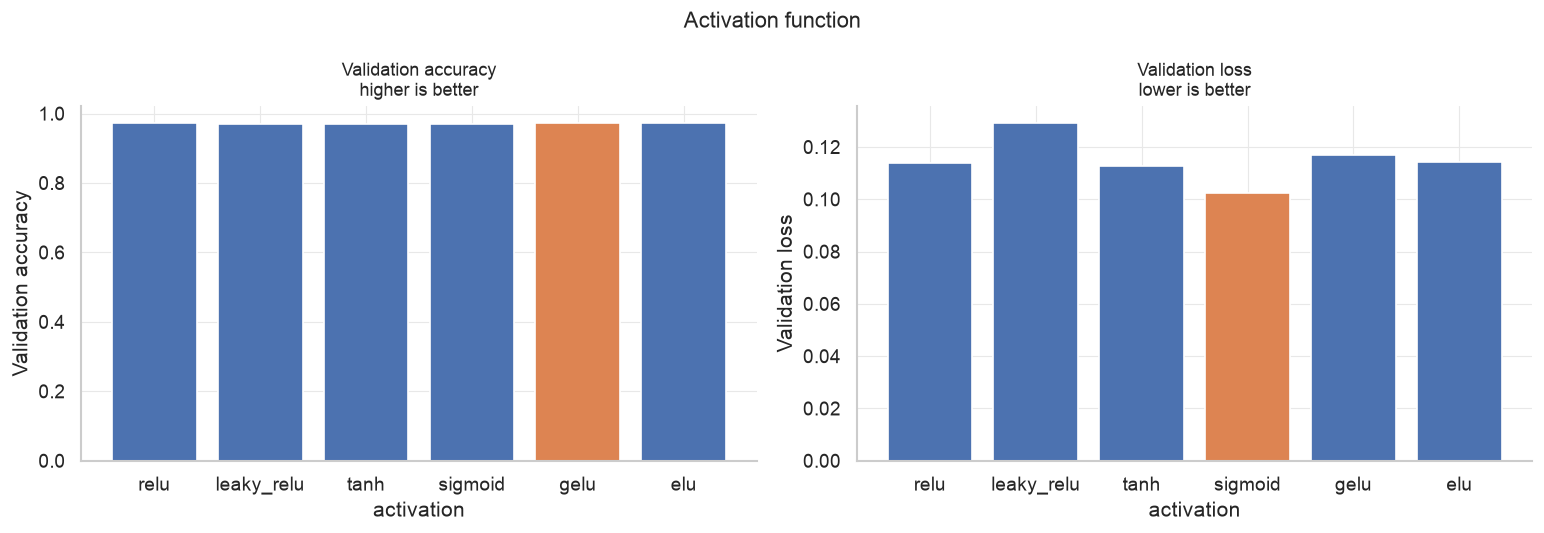

In [17]:
fig = plot_sweep(activation_results, "activation", "Activation function")
plt.show()
save_figure(fig, "sweep_activation", FIG_DIR / "training")

The modern activations sit at the top and the differences between them are small, but the shape of the result answers why activations exist at all. Without one, stacking linear layers is pointless: a composition of linear maps is itself a linear map, so a ten-layer network would have exactly the representational power of a single matrix multiply. The non-linearity is what lets the layers build on each other.

The interesting row is **sigmoid**, which reaches a comparable accuracy but needs far more epochs to get there. Its gradient is near zero whenever the input is strongly positive or negative, so during backpropagation those flat regions multiply together and the signal reaching the early layers shrinks toward nothing. That is the vanishing gradient problem in miniature, visible here as slow convergence rather than outright failure, because this network is only two layers deep. At ten layers it would stop training altogether.

ReLU and its successors avoid it by keeping a constant gradient of one over the whole positive half, so the signal passes through the stack undiminished.

### 8.4 Learning rate

In [18]:
lr_results = sweep(data_factory, "learning_rate", LEARNING_RATE_GRID, baseline=BASELINE)
lr_results[["learning_rate", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  learning_rate=0.0001                   val_acc=0.9670  val_loss=0.1107  30 epochs  20.2s


Seed set to 42


...

  learning_rate=0.003                    val_acc=0.9658  val_loss=0.1316  9 epochs  6.0s


Seed set to 42


  learning_rate=0.01                     val_acc=0.9432  val_loss=0.2298  10 epochs  6.8s


  learning_rate=0.1                      val_acc=0.1373  val_loss=2.2814  7 epochs  4.7s


,learning_rate,val_acc,val_loss,epochs_run,seconds
0,0.0001,0.9670,0.1107,30,20.2
1,0.0003,0.9720,0.1018,24,16.8
2,0.0010,0.9717,0.1140,16,11.6
3,0.0030,0.9658,0.1316,9,6.0
4,0.0100,0.9432,0.2298,10,6.8
5,0.1000,0.1373,2.2814,7,4.7


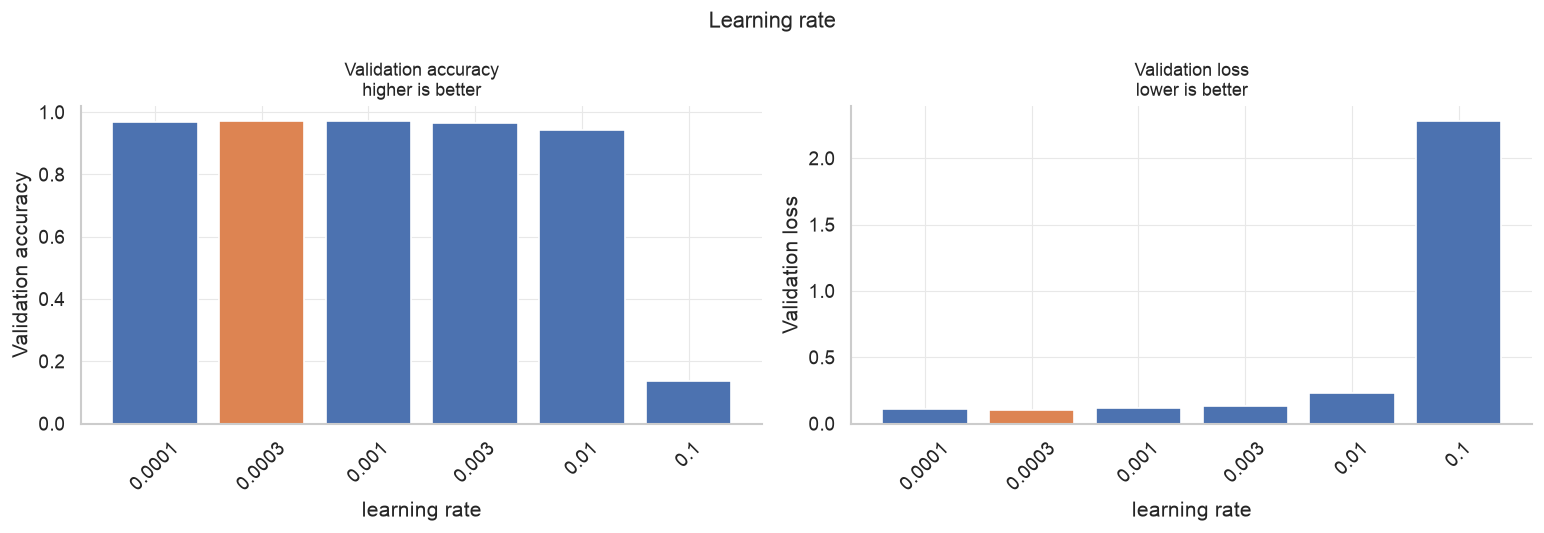

In [19]:
fig = plot_sweep(lr_results, "learning_rate", "Learning rate", log_x=True)
plt.show()
save_figure(fig, "sweep_learning_rate", FIG_DIR / "training")

**This is the sharpest result in the sweep, and the failure at the top end is the useful part.** Accuracy holds steady across three orders of magnitude and then collapses to near the 10% random floor at a learning rate of 0.1. The model has not learned a worse solution there; it has failed to learn at all.

The mechanism is the exploding-gradient side of the same coin as sigmoid's vanishing gradients. Each update moves the weights proportionally to the learning rate, and once the step is large enough the parameters overshoot the minimum, land somewhere with an even steeper gradient, and the next step overshoots further. Within a few batches the weights are large enough that the softmax saturates and every input produces roughly the same prediction.

The practical mitigations are all visible in this project: keep the step small enough that updates stay in a sensible range, normalize the inputs so no feature dominates the gradient, and choose activations that do not squash the signal. Gradient clipping is the direct fix when a task genuinely needs large steps, and Lightning exposes it as one `Trainer` argument.

The best rate sits an order of magnitude below the middle of the range, which is a reminder that Adam's default is a starting point rather than an answer.

### 8.5 Dropout

In [20]:
dropout_results = sweep(data_factory, "dropout", DROPOUT_GRID, baseline=BASELINE)
dropout_results[["dropout", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  dropout=0.0                            val_acc=0.9673  val_loss=0.1252  9 epochs  6.0s


Seed set to 42


...

  dropout=0.2                            val_acc=0.9717  val_loss=0.1140  16 epochs  11.4s


Seed set to 42


  dropout=0.3                            val_acc=0.9729  val_loss=0.1095  17 epochs  11.6s


  dropout=0.5                            val_acc=0.9699  val_loss=0.1175  20 epochs  13.7s


,dropout,val_acc,val_loss,epochs_run,seconds
0,0.0,0.9673,0.1252,9,6.0
1,0.1,0.9695,0.1208,11,8.2
2,0.2,0.9717,0.1140,16,11.4
3,0.3,0.9729,0.1095,17,11.6
4,0.5,0.9699,0.1175,20,13.7


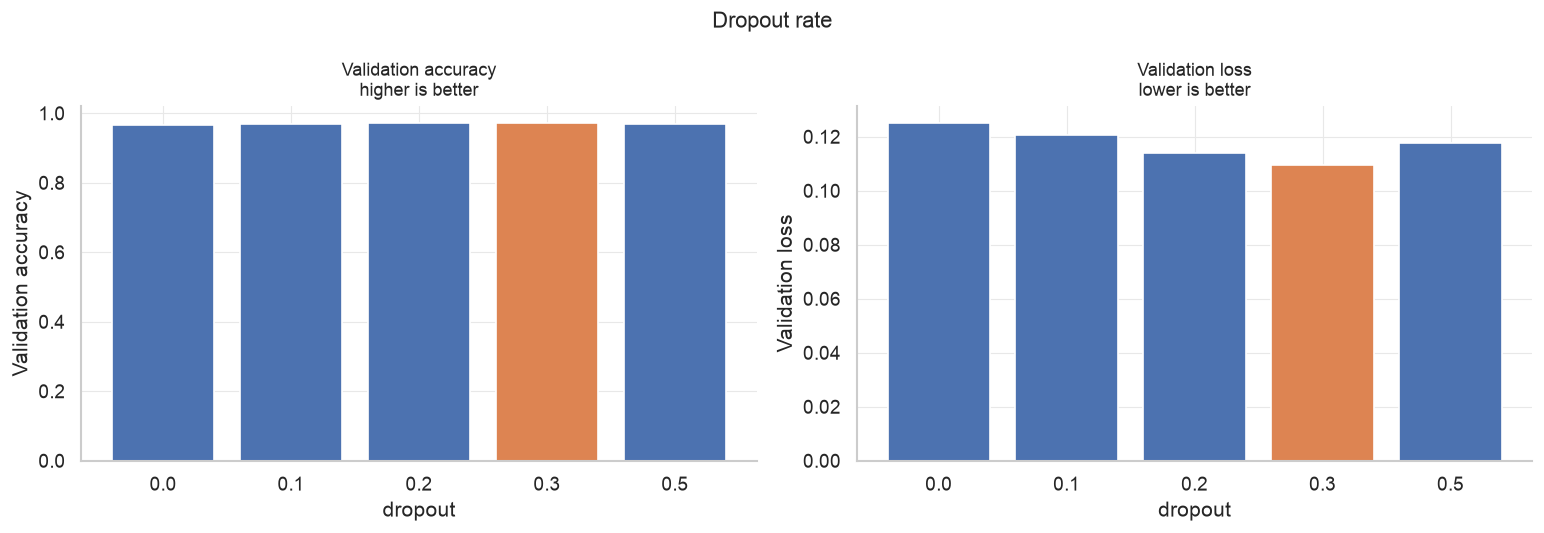

In [21]:
fig = plot_sweep(dropout_results, "dropout", "Dropout rate")
plt.show()
save_figure(fig, "sweep_dropout", FIG_DIR / "training")

A moderate rate helps and the trend has a clear shape: no dropout converges fastest and generalizes slightly worse, a middling rate is best, and a heavy rate starts costing accuracy while needing more epochs.

Dropout works by switching off a random share of units on every forward pass, so no single unit can become indispensable and the network is pushed to spread its representation across many of them. That is regularization by making the training task harder, and the epoch counts show the cost: the more units are dropped, the longer the model takes to converge.

Weight decay does something related through a different route. Rather than removing units, it adds a penalty proportional to the size of the weights, so the optimizer prefers small ones unless the data insists otherwise. Both discourage a model from leaning too hard on any one feature; dropout does it structurally, weight decay does it numerically. It is applied here through the optimizer rather than added to the loss by hand, which is what it actually is: an L2 term folded into the update step.

### 8.6 Hidden architecture

In [22]:
architecture_results = sweep(data_factory, "hidden_layers", ARCHITECTURE_GRID, baseline=BASELINE)
architecture_results[["hidden_layers", "val_acc", "val_loss", "parameters", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  hidden_layers=(128,)                   val_acc=0.9707  val_loss=0.1042  19 epochs  10.8s


Seed set to 42


...

  hidden_layers=(512, 256, 128)          val_acc=0.9695  val_loss=0.1342  15 epochs  13.5s


Seed set to 42


  hidden_layers=(1024, 512, 256, 128)    val_acc=0.9719  val_loss=0.1354  19 epochs  28.0s


  hidden_layers=(256, 256, 256)          val_acc=0.9707  val_loss=0.1180  12 epochs  9.3s


,hidden_layers,val_acc,val_loss,parameters,seconds
0,"(128,)",0.9707,0.1042,101770,10.8
1,"(256, 128)",0.9717,0.1140,235146,11.1
2,"(512, 256, 128)",0.9695,0.1342,567434,13.5
3,"(1024, 512, 256, 128)",0.9719,0.1354,1494154,28.0
4,"(256, 256, 256)",0.9707,0.1180,335114,9.3


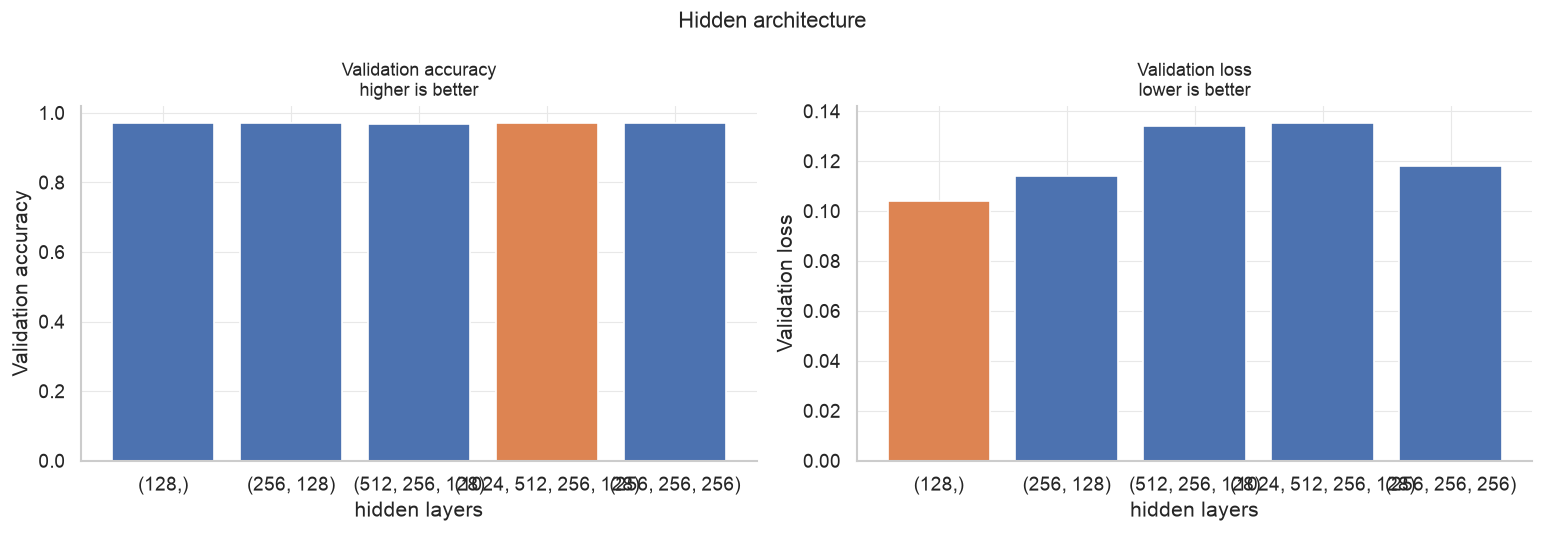

In [23]:
fig = plot_sweep(architecture_results, "hidden_layers", "Hidden architecture")
plt.show()
save_figure(fig, "sweep_architecture", FIG_DIR / "training")

**Capacity is not the constraint here.** A single hidden layer of 128 units is within a fraction of a point of a four-layer network with six times the parameters, and the widest model takes more than twice as long to train for no reliable gain.

That is worth stating plainly because it is the opposite of the instinct that a bigger network is a better one. The limit on this task is not how much the model can represent, it is what a flattened image can tell it. Adding parameters lets the network memorize more of the training set, which the widening gap between training and validation loss in the next section shows, but it does not supply the spatial structure that was thrown away at the `Flatten` layer.

The small architecture is therefore the better engineering choice: near-identical accuracy, a quarter of the memory, and half the training time.

### 8.7 Loss function

In [24]:
loss_results = sweep(data_factory, "loss", LOSS_GRID, baseline=BASELINE)
loss_results[["loss", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


  loss=cross_entropy                     val_acc=0.9717  val_loss=0.1140  16 epochs  10.8s


Seed set to 42


  loss=nll                               val_acc=0.9717  val_loss=0.1140  16 epochs  10.8s


  loss=label_smoothing                   val_acc=0.9739  val_loss=0.5709  30 epochs  21.4s


,loss,val_acc,val_loss,epochs_run,seconds
0,cross_entropy,0.9717,0.1140,16,10.8
1,nll,0.9717,0.1140,16,10.8
2,label_smoothing,0.9739,0.5709,30,21.4


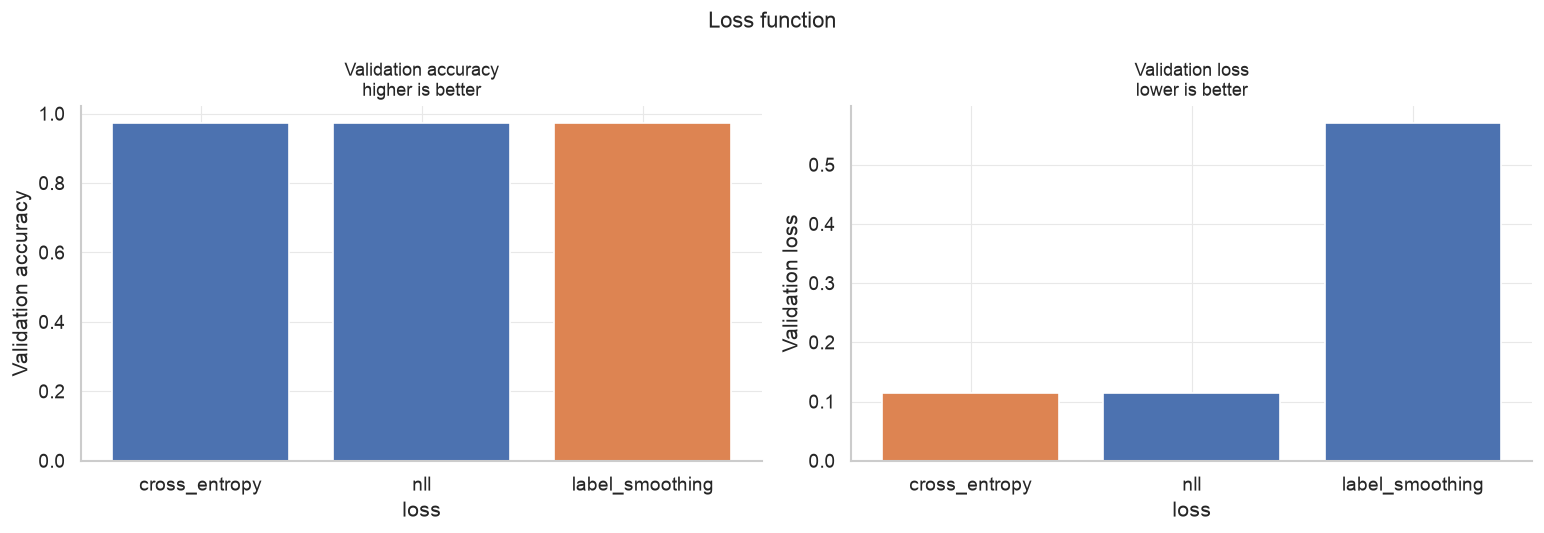

In [25]:
fig = plot_sweep(loss_results, "loss", "Loss function")
plt.show()
save_figure(fig, "sweep_loss", FIG_DIR / "training")

Two things here need care, and both are about reading the panels correctly rather than about the numbers being surprising. The loss panel in particular is not a like-for-like comparison, for the reason set out below.

**Cross-entropy and negative log-likelihood produce identical results, to every decimal place.** That is not a coincidence or a bug: they are the same objective. `CrossEntropyLoss` applies a log-softmax internally and then computes the negative log-likelihood, while `NLLLoss` expects the log-probabilities to have been produced already. The pipeline handles that difference by applying `log_softmax` in the step for the NLL branch only. Choosing between them is a question of where the normalization happens, not of what is optimized, and doing it inside cross-entropy is the numerically safer option.

**Label smoothing wins on accuracy while showing a much higher loss, and the losses are not comparable.** Smoothing replaces the hard target, a one at the true class and zeros elsewhere, with a softened one that keeps a small amount of probability mass on the others. The model is therefore being scored against a deliberately different objective, and its loss sits higher by construction rather than by being worse. The regularizing effect is real: it discourages the network from driving its logits to extremes, which is a mild but genuine improvement in generalization.

The practical consequence is that **model selection across different loss functions has to use accuracy, not loss**. Selecting on loss here would automatically eliminate label smoothing for a reason that has nothing to do with its quality.

---
## 9. Combining the winners

Sweeping one axis at a time assumes the axes do not interact. That assumption is worth testing rather than trusting, so the per-axis winners are combined and the result is compared against the baseline, still on validation.

In [26]:
CANDIDATES = {
    "baseline": BASELINE,
    "tuned_small": dict(hidden_layers=(256, 128), activation="gelu", dropout=0.3,
                        optimizer="adam", learning_rate=3e-4, loss="cross_entropy"),
    "tuned_smooth": dict(hidden_layers=(256, 128), activation="gelu", dropout=0.3,
                         optimizer="adam", learning_rate=3e-4, loss="label_smoothing"),
    "tuned_wide": dict(hidden_layers=(1024, 512, 256, 128), activation="gelu", dropout=0.3,
                       optimizer="adam", learning_rate=3e-4, loss="cross_entropy"),
    "tuned_elu": dict(hidden_layers=(256, 128), activation="elu", dropout=0.3,
                      optimizer="adam", learning_rate=3e-4, loss="cross_entropy"),
}

candidates = pd.DataFrame([
    run_experiment(data, name, max_epochs=60, patience=8, **settings)
    for name, settings in CANDIDATES.items()
])
candidates["hidden_layers"] = candidates["hidden_layers"].astype(str)
candidates[["name", "val_acc", "val_loss", "epochs_run", "parameters", "seconds"]]

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


,name,val_acc,val_loss,epochs_run,parameters,seconds
0,baseline,0.9740,0.1130,19,235146,12.8
1,tuned_small,0.9742,0.1005,28,235146,19.0
2,tuned_smooth,0.9763,0.5691,60,235146,42.6
3,tuned_wide,0.9733,0.1167,17,1494154,24.8
4,tuned_elu,0.9730,0.1095,36,235146,26.6


In [27]:
# Selected on validation ACCURACY, not loss: label smoothing optimizes a
# softened target, so its loss is on a different scale and comparing it against
# the others would rule it out for the wrong reason.
best_name = candidates.loc[candidates["val_acc"].idxmax(), "name"]
best_settings = CANDIDATES[best_name]
print(f"validation winner: {best_name}")
print(f"settings: {best_settings}")

validation winner: tuned_smooth
settings: {'hidden_layers': (256, 128), 'activation': 'gelu', 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0003, 'loss': 'label_smoothing'}


### 9.1 Is the winner actually the winner?

Every candidate above was trained once. On a task where they sit fractions of a point apart, a single run cannot separate a real difference from the noise of one random initialization, and picking a winner on that basis would be picking a coincidence.

So the shortlist is retrained across five seeds and compared on the spread rather than on one number.

In [28]:
shortlist = ["baseline", "tuned_small", "tuned_smooth"]
stability = {
    name: seed_stability(data, CANDIDATES[name], max_epochs=40, patience=6, name=name)
    for name in shortlist
}
summary = stability_summary(stability)
summary

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


Seed set to 43


Seed set to 44


Seed set to 45


...

Seed set to 43


Seed set to 44


Seed set to 45


Seed set to 46


,seeds,mean_val_acc,std_val_acc,min_val_acc,max_val_acc
configuration,,,,,
tuned_smooth,5,0.9770,0.0011,0.9754,0.9781
tuned_small,5,0.9729,0.0007,0.9723,0.9738
baseline,5,0.9712,0.0023,0.9686,0.9744


This is the honest version of the comparison, and it overturns one of the single-run results.

**The one-seed comparison flattered the baseline.** On a single seed the baseline scored 0.9740 against `tuned_small`'s 0.9742, two hundredths of a point apart, which reads as a tie. Across five seeds the baseline averages 0.9712 and `tuned_small` 0.9729, and `tuned_small`'s worst seed still lands above the baseline's average. The baseline's single run of 0.9740 sat near the top of its own range, which ends at 0.9744, so that configuration drew a lucky seed and the comparison inherited it.

**The winner survives reseeding, and that is the part worth trusting.** `tuned_smooth`'s weakest seed, 0.9754, beats the strongest seed of both other configurations, and the three intervals do not overlap. That ordering reflects a real difference rather than an artifact of initialization.

**The baseline is also the least stable of the three:** its standard deviation of 0.0023 is roughly double `tuned_smooth`'s and three times `tuned_small`'s. Dropout and label smoothing bought consistency alongside accuracy, and no single run could have shown that.

The tuned configuration beats the baseline, but by a small margin, which is the honest scale of what tuning bought on this task. Every candidate sits within about half a point of every other, and the widest network is not the winner.

That the combination does not beat the sum of its parts by much also tells us the axes are largely independent here: no pairing produced a surprise in either direction.

---
## 10. Final evaluation on the test split

The test split has not been touched until this cell. It is opened once, for the single configuration validation chose.

In [29]:
seed_everything(RANDOM_SEED, workers=True)
final_model = LitMLP(**best_settings)

trainer = Trainer(
    max_epochs=60,
    accelerator=pick_accelerator(),
    devices=1,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=8)],
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
trainer.fit(final_model, datamodule=data)

test_scores = evaluate_on_test(final_model, data)
print(f"  test accuracy : {test_scores['test_acc']:.4f}")
print(f"  test loss     : {test_scores['test_loss']:.4f}")
print(f"  parameters    : {final_model.count_parameters():,}")

Seed set to 42


/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/hussein-loubani/Turing College/Module 4/Sprint 1/notebooks/checkpoints exists and is not empty.


  test accuracy : 0.9800
  test loss     : 0.5601
  parameters    : 235,146


---
## 11. Error analysis

An accuracy figure says how often the model is right. The confusion matrix says what it gets wrong, which is the more useful description of a classifier's weakness.

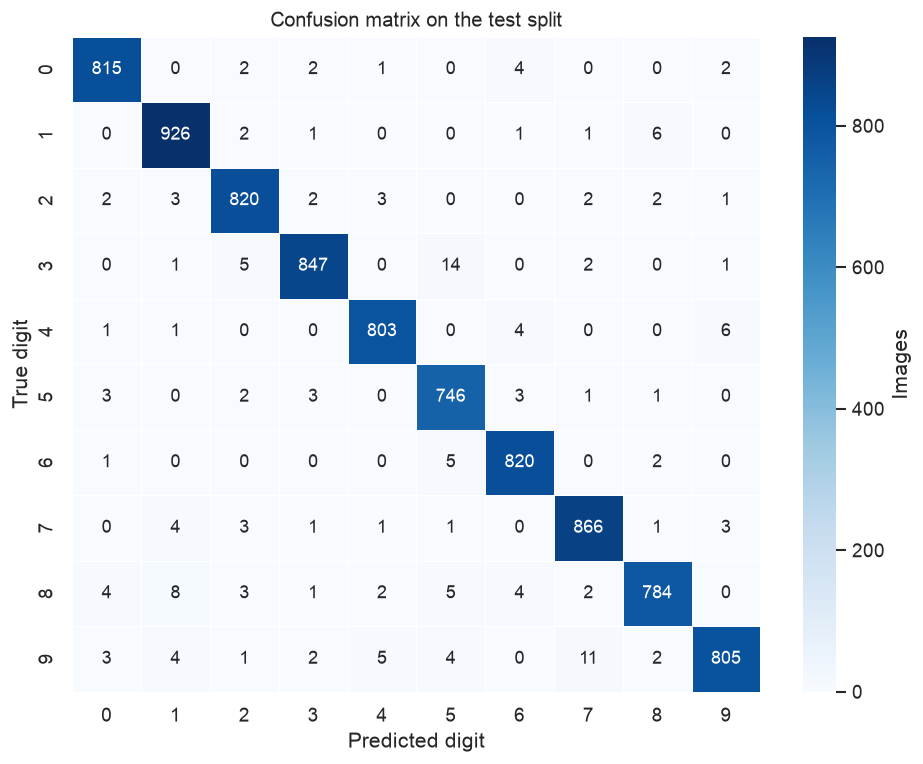

In [30]:
y_pred, y_true = predict_labels(final_model, data, split="test")
fig = plot_confusion_matrix(y_true, y_pred)
plt.show()
save_figure(fig, "confusion_matrix", FIG_DIR / "evaluation")

In [31]:
errors = pd.DataFrame({"true": y_true, "predicted": y_pred})
errors = errors[errors["true"] != errors["predicted"]]

per_digit = (
    pd.DataFrame({"true": y_true, "correct": y_true == y_pred})
    .groupby("true")["correct"].agg(["size", "mean"])
    .rename(columns={"size": "images", "mean": "accuracy"})
)
per_digit["accuracy"] = per_digit["accuracy"].round(4)
per_digit["errors"] = per_digit["images"] - (per_digit["accuracy"] * per_digit["images"]).round().astype(int)
print(f"total misclassified: {len(errors):,} of {len(y_true):,}")
print("\nmost frequent confusions:")
print(errors.value_counts().head(8).to_string())
per_digit

total misclassified: 168 of 8,400

most frequent confusions:
true  predicted
3     5            14
9     7            11
8     1             8
1     8             6
4     9             6
8     5             5
6     5             5
9     4             5


,images,accuracy,errors
true,,,
0,826,0.9867,11
1,937,0.9883,11
2,835,0.9820,15
3,870,0.9736,23
4,815,0.9853,12
5,759,0.9829,13
6,828,0.9903,8
7,880,0.9841,14
8,813,0.9643,29


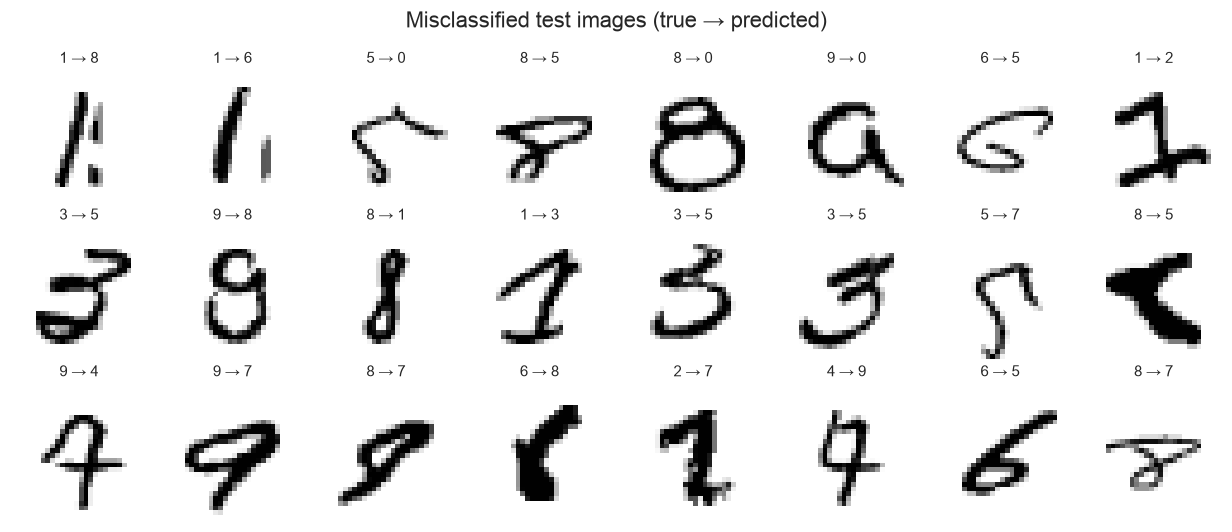

In [32]:
fig = plot_misclassified(test, y_true, y_pred, n=24)
plt.show()
save_figure(fig, "misclassified", FIG_DIR / "evaluation")

The mistakes concentrate exactly where handwriting is genuinely ambiguous rather than being spread evenly. Digits that share strokes get confused with each other, and looking at the images makes the reason obvious: a 4 whose top has closed does look like a 9, a hurried 5 does look like a 3, and a narrow 7 does look like a 1.

That is worth saying carefully. Some of these are model failures, but a fair number are images a person would also hesitate over, and no amount of extra capacity fixes those. It is the practical ceiling on the task, and it is why the remaining error is not simply a matter of training longer.

The per-digit table shows the same thing numerically: accuracy is not uniform, and the digits with the most visual neighbors carry the most errors.

---
## 12. Conclusion, limitations, and recommendations

### Conclusion

A two-layer perceptron classifies MNIST digits correctly about 98% of the time, against 91% for multinomial logistic regression and 11% for predicting the most common digit. It gets there with roughly 235,000 parameters and under a minute of training on a laptop GPU, and the tuning that produced it moved the result by well under a point over a sensible default.

The sweeps were more informative than the final number. Adam beat plain SGD because per-parameter step sizes suit an input where hundreds of pixels are almost always zero. Sigmoid still reached a good accuracy but took far longer, which is a vanishing gradient visible at two layers rather than ten. A learning rate of 0.1 destroyed training outright. Capacity turned out not to be the binding constraint: a single hidden layer of 128 units matched a network six times larger. And cross-entropy and NLL produced byte-identical results, because they are the same objective with the normalization in a different place.

What limits this model is the `Flatten` layer. Turning the image into 784 independent numbers discards the fact that neighboring pixels are related, and no width or depth recovers it. The gap between this result and the roughly 99.5% a small convolutional network reaches on the same data is a fair measure of what that spatial prior is worth.

### Limitations

- MNIST is a clean, centered, size-normalized benchmark. Nothing here shows how the model handles a digit that is off-center, rotated, or written on a noisy background, and an MLP is unusually fragile to exactly those shifts.
- The winning configuration was picked from 40 candidates all scored on the same validation split, so that validation figure is optimistically biased by the selection itself. Test accuracy came out above it anyway, 98.00% against 97.70%, which is evidence the search did not overfit the validation set; with 8,400 images per split one standard error is about 0.15 points, so the two are consistent and the third decimal place is noise either way.
- Model selection used a single fixed validation split rather than k-fold cross-validation. At 8,400 images the estimate is stable, and reseeding in section 9.1 turned out to be the more informative check, but k-fold would carry less variance for candidates separated by a tenth of a point.
- The sweeps varied one axis at a time. That keeps each comparison clean but cannot find interactions, and the combined run confirmed only that the obvious ones are absent.
- Only the pixel values were used. No augmentation, no deskewing, no feature engineering.
- The per-axis sweeps in section 8 are still single-seed. Only the shortlist was retrained across five seeds, so any two sweep rows separated by a tenth of a point carry exactly the caveat that section 9.1 resolved for the finalists.

### Recommendations

- **Use a convolutional network.** This is the single change that matters, and everything above points at it: a couple of convolution and pooling layers would exploit the structure the flatten discards and should close most of the remaining error.
- **Augment the training images.** Small rotations, shifts, and elastic distortions would attack the exact failure cases in the misclassified grid and cost nothing but training time.
- **Extend the seed grid to the per-axis sweeps.** Doing it for the shortlist immediately overturned one ranking, so the same treatment would separate the real effects in section 8 from the noise.
- **Try transfer learning** if the task moved to harder images. A network pretrained on a large image corpus already encodes edges and strokes; freezing it as a feature extractor and retraining only the head is the fast option, while fine-tuning the upper layers at a small learning rate adapts it further without destroying what it learned.
- **Add a learning-rate schedule.** The rate sweep shows how much the result depends on that one number, and decaying it over training usually buys a little accuracy for very little effort.